In [5]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
#loading data
df = pd.read_csv('/content/drive/MyDrive/Data/SMS_ANALYSIS.csv')

In [8]:
#fidt five rows
df.head(5)

,platform,post_id,user_id,username,user_verified,user_followers_count,user_location,post_text,language,hashtags,...,day_of_week,is_trending_topic,topic_category,sentiment_label,sentiment_score,emotion_label,toxicity_score,sarcasm_detected,spam_flag,data_source_url
0,YouTube,YO_100000,user_2679,rxckafna,True,375410,Germany,I don’t agree with this at all.,ur,"#news,#update",...,Wed,True,Technology,Positive,0.82,Sad,0.10,False,True,https://www.youtube.com
1,Reddit,RE_100001,user_3045,zjovqwps,True,346702,UK,Worst decision ever made.,fr,"#trending,#ai",...,Tue,False,Sports,Neutral,-0.02,Angry,0.67,True,True,https://www.reddit.com
2,YouTube,YO_100002,user_4598,rvufaigf,False,111487,Germany,This trend is getting out of hand.,de,"#news,#update",...,Fri,False,Finance,Positive,0.62,Neutral,0.43,False,False,https://www.youtube.com
3,Twitter,TW_100003,user_3504,qukbjznz,True,356674,Germany,Pretty neutral about the update.,en,"#trending,#ai",...,Thu,True,Finance,Neutral,0.14,Sad,0.97,True,True,https://www.twitter.com
4,YouTube,YO_100004,user_3646,ounaiayw,False,125551,USA,"Loved the explanation, very helpful.",es,"#trending,#ai",...,Sun,True,Technology,Neutral,-0.05,Fear,0.95,True,False,https://www.youtube.com


In [9]:
df.tail(5)

,platform,post_id,user_id,username,user_verified,user_followers_count,user_location,post_text,language,hashtags,...,day_of_week,is_trending_topic,topic_category,sentiment_label,sentiment_score,emotion_label,toxicity_score,sarcasm_detected,spam_flag,data_source_url
2195,Twitter,TW_102195,user_5562,wbmdjeyg,False,416073,Canada,This is absolutely amazing!,es,"#trending,#ai",...,Sat,True,Climate,Neutral,0.07,Fear,0.75,True,False,https://www.twitter.com
2196,Twitter,TW_102196,user_7076,jgagwoun,False,101979,Canada,I’m confused about the announcement.,ur,"#news,#update",...,Wed,False,Technology,Neutral,0.15,Fear,0.95,False,True,https://www.twitter.com
2197,YouTube,YO_102197,user_9327,ubafeuzh,True,386908,UK,"Not bad, but could be better.",ur,"#trending,#ai",...,Mon,False,Sports,Negative,-0.90,Fear,0.25,True,False,https://www.youtube.com
2198,Reddit,RE_102198,user_4002,zahccrkp,False,266478,UK,I’m confused about the announcement.,es,"#trending,#ai",...,Sun,True,Finance,Positive,0.91,Fear,0.43,True,False,https://www.reddit.com
2199,YouTube,YO_102199,user_4688,tolbdysn,False,338860,India,This is absolutely amazing!,fr,"#news,#update",...,Sat,True,Finance,Neutral,-0.19,Angry,0.13,False,False,https://www.youtube.com


In [10]:
df.describe()

,user_followers_count,post_length,like_count,comment_count,share_count,engagement_score,sentiment_score,toxicity_score
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,251563.535455,31.432273,10009.355909,2475.158636,1471.210455,0.508855,0.010514,0.501041
std,143956.859442,3.764069,5885.532782,1425.979361,877.520927,0.293027,0.556477,0.284087
min,139.000000,25.000000,11.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,127377.750000,29.000000,4859.500000,1239.250000,700.750000,0.260000,-0.450000,0.260000
50%,246535.500000,31.000000,9758.500000,2437.500000,1458.000000,0.520000,0.010000,0.500000
75%,375852.000000,36.000000,15310.000000,3725.750000,2238.250000,0.760000,0.472500,0.740000
max,499778.000000,36.000000,20000.000000,5000.000000,3000.000000,1.000000,1.000000,1.000000


In [11]:
df.isnull().sum()

,0
platform,0
post_id,0
user_id,0
username,0
user_verified,0
user_followers_count,0
user_location,0
post_text,0
language,0
hashtags,0


UNIVARIATE ANALYSIS

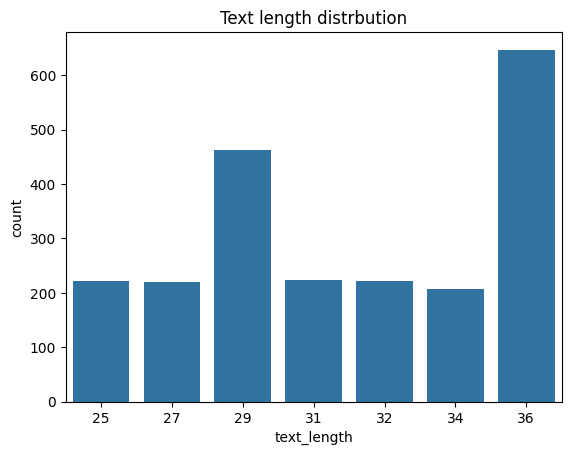

In [12]:
#text length
df['text_length'] = df['post_text'].apply(len)
sns.countplot(x= df['text_length'])
plt.title("Text length distrbution")
plt.show()

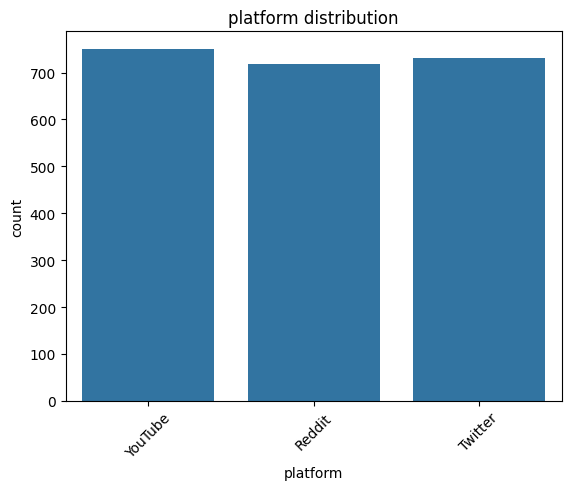

In [13]:
#platform distribution
sns.countplot(x='platform', data=df)
plt.xticks(rotation=45)
plt.title("platform distribution")
plt.show()


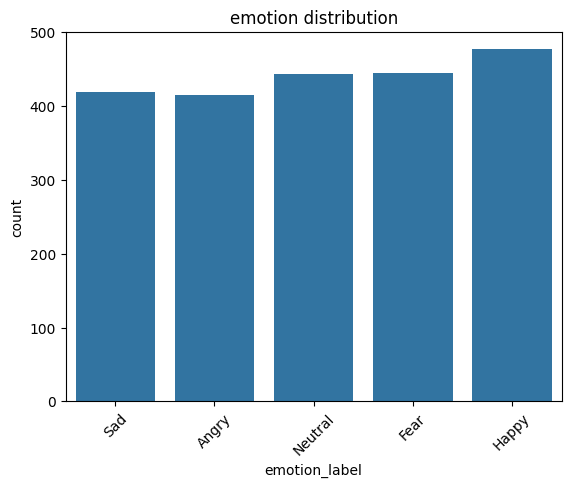

In [14]:
sns.countplot(x='emotion_label', data=df)
plt.xticks(rotation=45)
plt.title("emotion distribution")
plt.show()

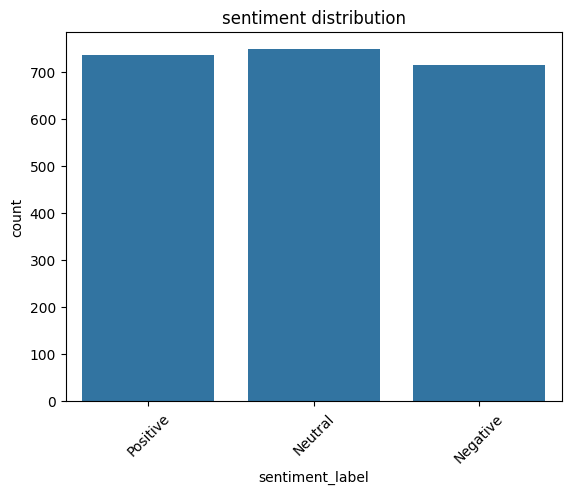

In [15]:
sns.countplot(x='sentiment_label', data=df)
plt.xticks(rotation=45)
plt.title("sentiment distribution")
plt.show()

BIVARIATE ANALYSIS

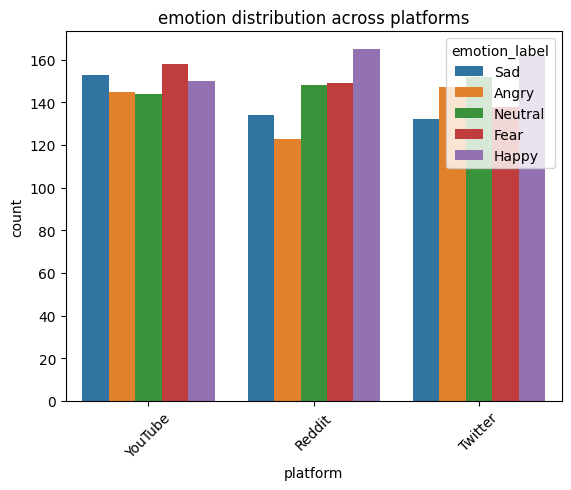

In [16]:
#How does emotion vary across platforms?
sns.countplot(x='platform', hue='emotion_label', data=df)
plt.xticks(rotation=45)
plt.title("emotion distribution across platforms")
plt.show()

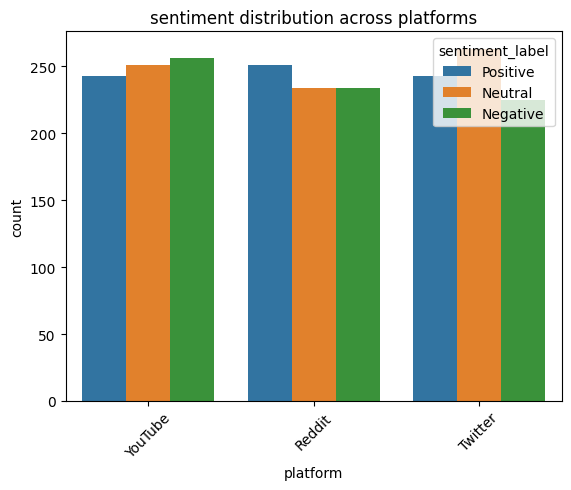

In [17]:
#How does sentiment vary across platforms?
sns.countplot(x='platform', hue='sentiment_label', data=df)
plt.xticks(rotation=45)
plt.title("sentiment distribution across platforms")
plt.show()

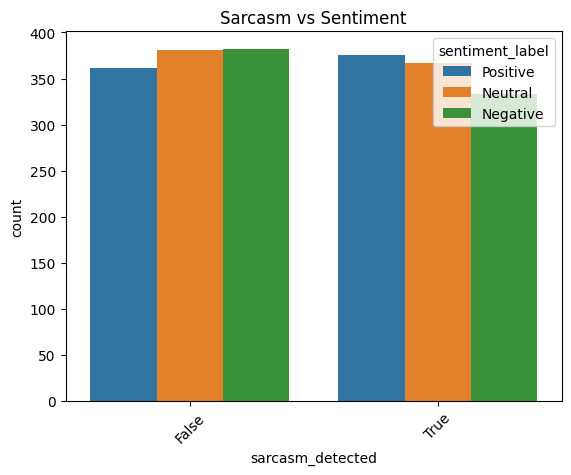

In [18]:
sns.countplot(x='sarcasm_detected', hue='sentiment_label', data=df)
plt.xticks(rotation=45)
plt.title("Sarcasm vs Sentiment")
plt.show()

SENTIMENT ANALYSIS for Post Comment

In [19]:
import pandas as pd
import re
import string
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

#Initialize NLP tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

#Define preprocessing function
def preprocess_text(text):
    text = str(text).lower()                              # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)           # remove URLs
    text = re.sub(r"@\w+", "", text)                     # remove mentions
    text = re.sub(r"#", "", text)                        # remove hashtag symbol
    text = re.sub(r"\d+", "", text)                      # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()             # remove extra spaces

    tokens = word_tokenize(text)                         # tokenization
    tokens = [word for word in tokens if word not in stop_words]   # stopword removal
    tokens = [lemmatizer.lemmatize(word) for word in tokens]       # lemmatization

    return tokens
df["tokens"] = df["post_text"].apply(preprocess_text)
df["clean_text"] = df["tokens"].apply(lambda words: " ".join(words))
#Post length feature
df["post_length"] = df["tokens"].apply(len)
print(df[["post_text", "tokens", "clean_text", "post_length"]].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


                              post_text                         tokens  \
0       I don’t agree with this at all.                     [’, agree]   
1             Worst decision ever made.  [worst, decision, ever, made]   
2    This trend is getting out of hand.         [trend, getting, hand]   
3      Pretty neutral about the update.      [pretty, neutral, update]   
4  Loved the explanation, very helpful.  [loved, explanation, helpful]   

                  clean_text  post_length  
0                    ’ agree            2  
1   worst decision ever made            4  
2         trend getting hand            3  
3      pretty neutral update            3  
4  loved explanation helpful            3  


In [20]:
#Most frequent words
from collections import Counter

all_words = [word for tokens in df["tokens"] for word in tokens]
word_freq = Counter(all_words)

print(word_freq.most_common(20))

[('’', 466), ('confused', 243), ('announcement', 243), ('deserves', 243), ('attention', 243), ('agree', 223), ('worst', 221), ('decision', 221), ('ever', 221), ('made', 221), ('pretty', 221), ('neutral', 221), ('update', 221), ('bad', 219), ('could', 219), ('better', 219), ('absolutely', 219), ('amazing', 219), ('trend', 207), ('getting', 207)]


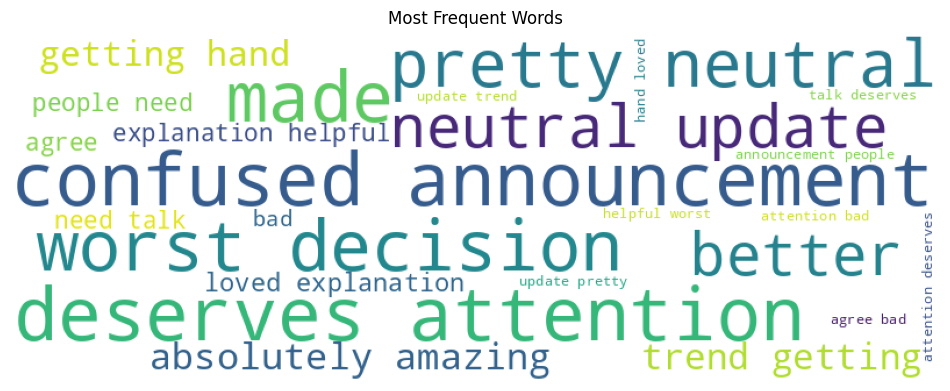

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(all_words)

wordcloud = WordCloud(width=800, height=300, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

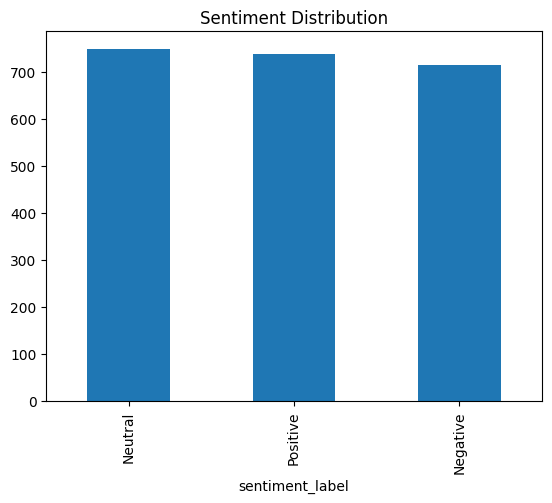

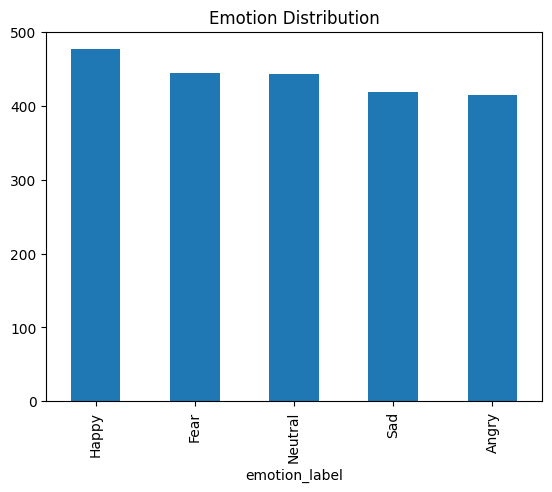

In [22]:
df["sentiment_label"].value_counts().plot(kind="bar", title="Sentiment Distribution")
plt.show()

df["emotion_label"].value_counts().plot(kind="bar", title="Emotion Distribution")
plt.show()

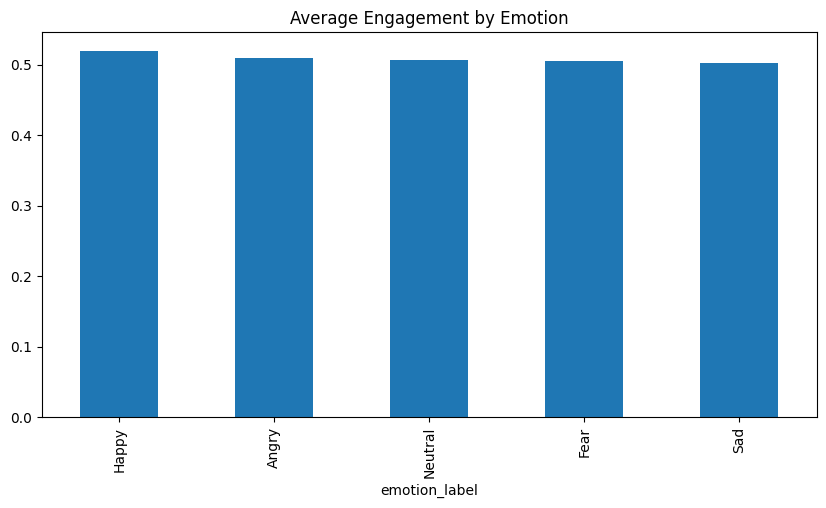

In [23]:
#emotion driving Engagement
df.groupby("emotion_label")["engagement_score"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Average Engagement by Emotion")
plt.show()

In [24]:
#Sentiment Prediction Model
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X = df["clean_text"]
y = df["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.3613636363636364
              precision    recall  f1-score   support

    Negative       0.44      0.10      0.17       143
     Neutral       0.39      0.35      0.37       150
    Positive       0.34      0.63      0.44       147

    accuracy                           0.36       440
   macro avg       0.39      0.36      0.32       440
weighted avg       0.39      0.36      0.33       440



In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB

X = df["clean_text"]
y = df["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, max_df=0.95)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.3613636363636364
              precision    recall  f1-score   support

    Negative       0.44      0.10      0.17       143
     Neutral       0.39      0.35      0.37       150
    Positive       0.34      0.63      0.44       147

    accuracy                           0.36       440
   macro avg       0.39      0.36      0.32       440
weighted avg       0.39      0.36      0.33       440



In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.3613636363636364
              precision    recall  f1-score   support

    Negative       0.44      0.10      0.17       143
     Neutral       0.39      0.35      0.37       150
    Positive       0.34      0.63      0.44       147

    accuracy                           0.36       440
   macro avg       0.39      0.36      0.32       440
weighted avg       0.39      0.36      0.33       440



In [28]:
#Topic Modelling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_features=1000, stop_words='english')
X_topics = vectorizer.fit_transform(df["clean_text"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_topics)

feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:]]
    print(f"Topic {topic_idx+1}: {', '.join(top_words)}")

Topic 1: need, talk, agree, attention, deserves, decision, worst, hand, getting, trend
Topic 2: talk, need, deserves, attention, decision, worst, update, pretty, neutral, agree
Topic 3: need, agree, attention, deserves, decision, worst, bad, better, confused, announcement
Topic 4: need, people, talk, agree, attention, deserves, decision, worst, absolutely, amazing
Topic 5: need, people, talk, explanation, helpful, loved, decision, worst, attention, deserves


Top Topics with Negative Sentiment:

topic_category
Politics         115
Climate          112
Finance          111
Technology       108
Sports            96
Entertainment     95
Health            78
Name: count, dtype: int64


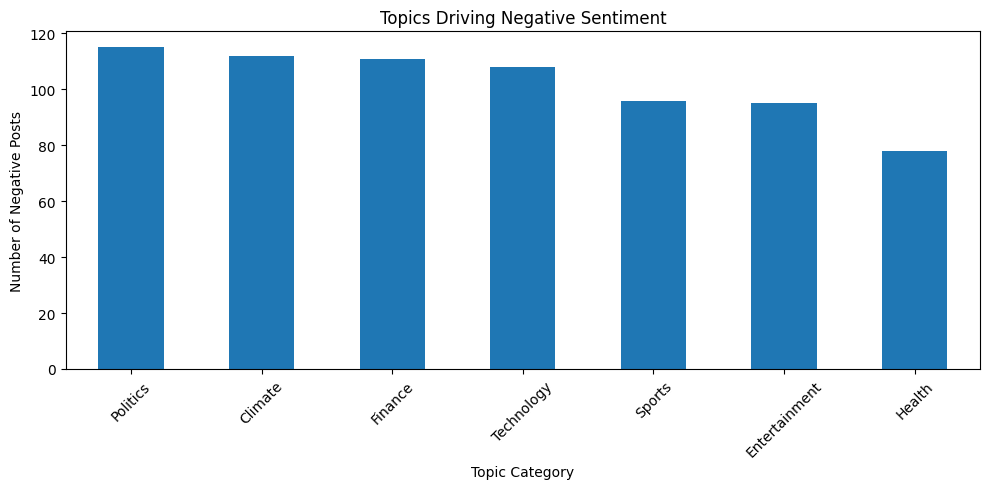


Top Hashtags with Negative Sentiment:

#update      364
#news        364
#ai          351
#trending    351
Name: count, dtype: int64


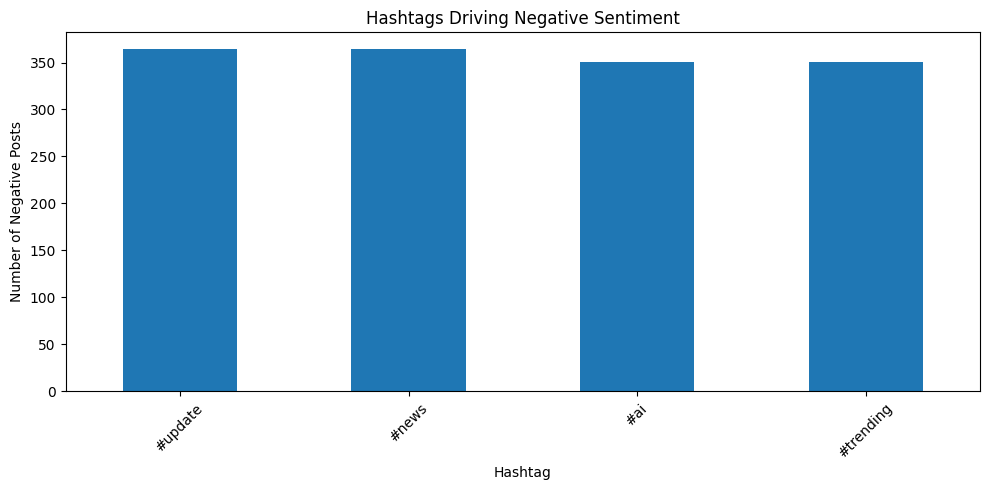

In [29]:
# Negative posts only
negative_posts = df[df["sentiment_label"] == "Negative"]

# Top topics driving negative sentiment
negative_topics = negative_posts["topic_category"].value_counts()
print("Top Topics with Negative Sentiment:\n")
print(negative_topics)

negative_topics.plot(kind="bar", figsize=(10,5), title="Topics Driving Negative Sentiment")
plt.xlabel("Topic Category")
plt.ylabel("Number of Negative Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Top hashtags driving negative sentiment
negative_hashtags = negative_posts["hashtags"].dropna().str.split(",")

all_hashtags = []
for tags in negative_hashtags:
    all_hashtags.extend([tag.strip() for tag in tags if tag.strip() != ""])

hashtag_counts = pd.Series(all_hashtags).value_counts()

print("\nTop Hashtags with Negative Sentiment:\n")
print(hashtag_counts)

hashtag_counts.head(10).plot(kind="bar", figsize=(10,5), title="Hashtags Driving Negative Sentiment")
plt.xlabel("Hashtag")
plt.ylabel("Number of Negative Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()